**Cell 1: Imports**

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

**Cell 2: Problem Setup**

In [2]:
NUM_NURSES = 4
DAYS = 5

# 0 = Off, 1 = Morning, 2 = Evening, 3 = Night
SHIFTS = [0, 1, 2, 3]

MAX_SHIFTS = 4
POP_SIZE = 20
GENERATIONS = 50

**Cell 3: Create Individual (Genotype)**

In [3]:
def create_individual():
    return np.random.choice(SHIFTS, size=(NUM_NURSES, DAYS))

**Cell 4: Fitness Function**

In [4]:
def fitness(individual):
    penalty = 0

    # Constraint 1: max shifts per nurse
    for nurse in individual:
        work_days = np.count_nonzero(nurse)
        if work_days > MAX_SHIFTS:
            penalty += (work_days - MAX_SHIFTS) * 2

    # Constraint 2: at least one working nurse per day
    for day in range(DAYS):
        if np.all(individual[:, day] == 0):
            penalty += 5

    return -penalty

**Cell 5: Selection**

In [5]:
def select(population):
    return max(random.sample(population, 3), key=fitness)

**Cell 6: Crossover**

In [6]:
def crossover(parent1, parent2):
    point = random.randint(1, DAYS - 1)
    child = np.hstack((parent1[:, :point], parent2[:, point:]))
    return child

**Cell 7: Mutation**

In [7]:
def mutate(individual):
    if random.random() < 0.3:
        nurse = random.randint(0, NUM_NURSES - 1)
        day = random.randint(0, DAYS - 1)
        individual[nurse][day] = random.choice(SHIFTS)
    return individual

**Cell 8: GA Main Loop + Tracking**

In [8]:
def run_ga():
    population = [create_individual() for _ in range(POP_SIZE)]
    fitness_history = []

    for gen in range(GENERATIONS):
        new_population = []

        for _ in range(POP_SIZE):
            p1 = select(population)
            p2 = select(population)

            child = crossover(p1, p2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

        best = max(population, key=fitness)
        best_fit = fitness(best)
        fitness_history.append(best_fit)

        print(f"Generation {gen}: Fitness = {best_fit}")

    return best, fitness_history

**Cell 9: Run GA**

In [9]:
best_solution, history = run_ga()

print("\nBest Schedule:\n")
print(best_solution)

Generation 0: Fitness = 0
Generation 1: Fitness = 0
Generation 2: Fitness = 0
Generation 3: Fitness = 0
Generation 4: Fitness = 0
Generation 5: Fitness = 0
Generation 6: Fitness = 0
Generation 7: Fitness = 0
Generation 8: Fitness = 0
Generation 9: Fitness = 0
Generation 10: Fitness = 0
Generation 11: Fitness = 0
Generation 12: Fitness = 0
Generation 13: Fitness = 0
Generation 14: Fitness = 0
Generation 15: Fitness = 0
Generation 16: Fitness = 0
Generation 17: Fitness = 0
Generation 18: Fitness = 0
Generation 19: Fitness = 0
Generation 20: Fitness = 0
Generation 21: Fitness = 0
Generation 22: Fitness = 0
Generation 23: Fitness = 0
Generation 24: Fitness = 0
Generation 25: Fitness = 0
Generation 26: Fitness = 0
Generation 27: Fitness = 0
Generation 28: Fitness = 0
Generation 29: Fitness = 0
Generation 30: Fitness = 0
Generation 31: Fitness = 0
Generation 32: Fitness = 0
Generation 33: Fitness = 0
Generation 34: Fitness = 0
Generation 35: Fitness = 0
Generation 36: Fitness = 0
Generation 

**Cell 10: Heatmap Visualization**

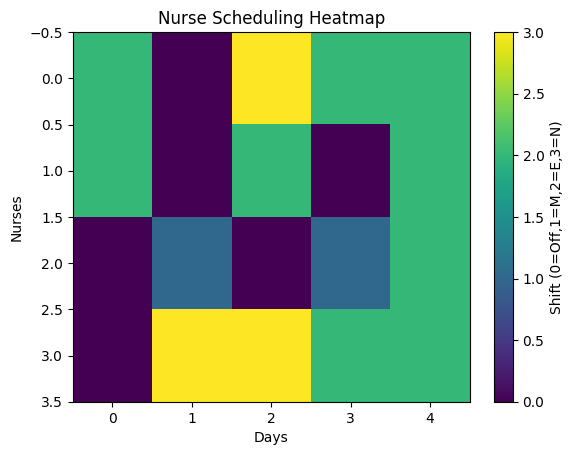

In [10]:
def visualize_schedule(schedule):
    plt.imshow(schedule, aspect='auto')
    plt.title("Nurse Scheduling Heatmap")
    plt.xlabel("Days")
    plt.ylabel("Nurses")
    plt.colorbar(label="Shift (0=Off,1=M,2=E,3=N)")
    plt.show()

visualize_schedule(best_solution)

**Cell 11: Fitness Evolution Chart**

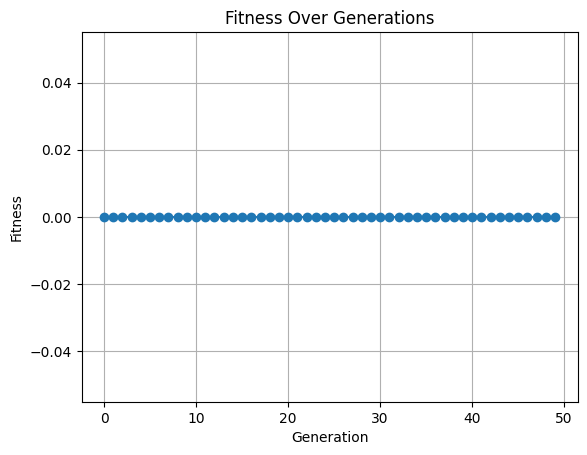

In [11]:
plt.plot(history, marker='o')
plt.title("Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()

**Cell 12: Best Generation Detection**

In [12]:
best_gen = history.index(max(history))
print("Best solution found at generation:", best_gen)

Best solution found at generation: 0


**Cell 13: Highlight Best Point**

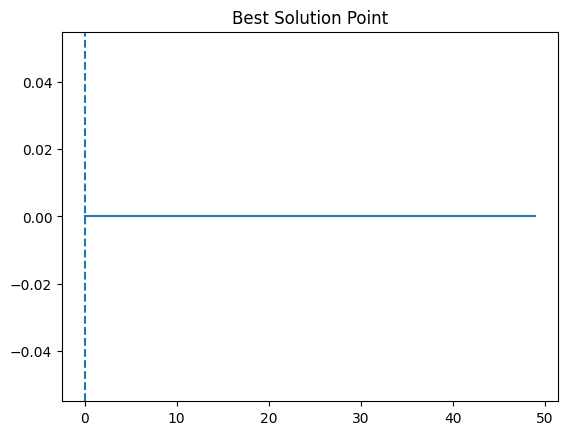

In [13]:
plt.plot(history)
plt.axvline(x=best_gen, linestyle='--')
plt.title("Best Solution Point")
plt.show()